# Objective: Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms using NLP techniques. Implement and compare multiple approaches for text prediction and spelling correction on a real text dataset. 

### Tech Stack: Python, pandas, NLTK, pyspellchecker or textdistance, collections, matplotlib, Jupyter Notebook 

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import nltk
import string
import re

# Collections
from collections import Counter, defaultdict

# Visualization
import matplotlib.pyplot as plt

# Spell correction
from spellchecker import SpellChecker

# Evaluation
from sklearn.metrics import confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Download NLTK resources

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("gutenberg")
nltk.download("words")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhavy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhavy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\bhavy\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\bhavy\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [3]:
# Load only first 10 million characters

with open("data/scraped_data.txt", "r", encoding="utf-8", errors="ignore") as file:
    corpus = file.read(10_000_000)

print("Characters Loaded :", len(corpus))

Characters Loaded : 10000000


The dataset used in this project is the Wikipedia Text Corpus downloaded from Kaggle.

Since the complete dataset is extremely large (approximately 730 MB), only the first 10 million characters are loaded. This subset is sufficiently large for building autocomplete and autocorrect models while significantly reducing processing time and memory usage.

In [4]:
print(corpus[:2000])

Title: Wikipedia, the free encyclopedia

Content: Wikipedia, the free encyclopedia Jump to content Main menu Main menu move to sidebar hide Navigation Main page Contents Current events Random article About Wikipedia Contact us Donate Contribute Help Learn to edit Community portal Recent changes Upload file Search Search Create account Log in Personal tools Create account Log in Pages for logged out editors learn more Contributions Talk Main Page Main Page Talk English Read View source View history Tools Tools move to sidebar hide Actions Read View source View history General What links here Related changes Upload file Special pages Permanent link Page information Cite this page Get shortened URL Wikidata item Print/export Download as PDF Printable version In other projects Wikimedia Commons Wikimedia Foundation MediaWiki Meta-Wiki Wikimedia Outreach Multilingual Wikisource Wikispecies Wikibooks Wikidata Wikifunctions Wikimania Wikinews Wikiquote Wikisource Wikiversity Wikivoyage Wiktio

In [5]:
characters=len(corpus)
words= corpus.split()
sentnces= nltk.sent_tokenize(corpus)

print("Total characters: ", characters)
print("Total words: ",len(words))
print("Total sentences: ",len(sentnces))

Total characters:  10000000
Total words:  1572566
Total sentences:  82746


In [6]:
import sys
print(f"corpus size in memory: {sys.getsizeof(corpus)/1024/1024:.2f} MB")

corpus size in memory: 38.15 MB


NLP Processing


In [7]:
#converting to lower case
corpus=corpus.lower()
print(corpus[:500])

title: wikipedia, the free encyclopedia

content: wikipedia, the free encyclopedia jump to content main menu main menu move to sidebar hide navigation main page contents current events random article about wikipedia contact us donate contribute help learn to edit community portal recent changes upload file search search create account log in personal tools create account log in pages for logged out editors learn more contributions talk main page main page talk english read view source view histo


In [8]:
#Remove numbers
corpus=re.sub(r"\d+"," ", corpus)
print(corpus[:500])

title: wikipedia, the free encyclopedia

content: wikipedia, the free encyclopedia jump to content main menu main menu move to sidebar hide navigation main page contents current events random article about wikipedia contact us donate contribute help learn to edit community portal recent changes upload file search search create account log in personal tools create account log in pages for logged out editors learn more contributions talk main page main page talk english read view source view histo


In [9]:
#remove punctuation
corpus= corpus.translate(str.maketrans("","", string.punctuation))

In [10]:
# Remove extra spaces

corpus = re.sub(r"\s+", " ", corpus).strip()
print(corpus[:500])

title wikipedia the free encyclopedia content wikipedia the free encyclopedia jump to content main menu main menu move to sidebar hide navigation main page contents current events random article about wikipedia contact us donate contribute help learn to edit community portal recent changes upload file search search create account log in personal tools create account log in pages for logged out editors learn more contributions talk main page main page talk english read view source view history to


# Tokenization

Tokenization is the process of splitting a sentence into individual words called **tokens**.

Example:

Sentence:

Natural Language Processing is amazing.

Tokens:

["natural", "language", "processing", "is", "amazing"]

Tokenization is the foundation of almost every NLP application.

In [11]:
from nltk.tokenize import word_tokenize

token= word_tokenize(corpus)
print("total number of tokens are: ", len(token))

print("first 50 tokens are:\n")
print(token[:50])

total number of tokens are:  1365498
first 50 tokens are:

['title', 'wikipedia', 'the', 'free', 'encyclopedia', 'content', 'wikipedia', 'the', 'free', 'encyclopedia', 'jump', 'to', 'content', 'main', 'menu', 'main', 'menu', 'move', 'to', 'sidebar', 'hide', 'navigation', 'main', 'page', 'contents', 'current', 'events', 'random', 'article', 'about', 'wikipedia', 'contact', 'us', 'donate', 'contribute', 'help', 'learn', 'to', 'edit', 'community', 'portal', 'recent', 'changes', 'upload', 'file', 'search', 'search', 'create', 'account', 'log']


# Stopwords

Stopwords are very common words such as:

- the
- is
- are
- of
- in
- and

For many NLP tasks, removing stopwords helps reduce noise.

However, for **autocomplete**, stopwords are important because they help preserve natural sentence structure.

Therefore:

- A copy of the token list will retain stopwords for autocomplete.
- Another copy will remove stopwords for frequency analysis.

In [12]:
from nltk.corpus import stopwords

stop_words= set(stopwords.words("english"))

#tokens for autocomplete (keep stopwords)
autocomplete_tokens= token.copy()

#tokens for EDA(remove stopwords)
clean_tokens= [word for word in token if word not in stop_words and word.isalpha()]

print("tokens with stopwords: ", len(autocomplete_tokens))
print("tokens without stopwords: ", len(clean_tokens))


tokens with stopwords:  1365498
tokens without stopwords:  954676


# Vocabulary

The vocabulary is the collection of all unique words present in the corpus after preprocessing.

A larger vocabulary generally improves the diversity of autocomplete suggestions and increases the range of words that can be corrected by the autocorrect system.

In [13]:
#count unique words
vocabulary= set(clean_tokens)
print("vocabulary size: ", len(vocabulary))

vocabulary size:  77572


In [14]:
print("sample vocabulary:\n")
print(list(vocabulary)[:50])

sample vocabulary:

['threats', 'goksedef', 'marini', 'deregulating', 'templatecontents', 'barracks', 'anneke', 'userexamplesubpage', 'gunther', 'galaxies', 'psychoanalysis', 'ea', 'בצהל', 'brackish', 'vt', 'thermography', 'bombers', 'ornamentation', 'chaminda', 'interfaculty', 'userporkchopgmxpopularity', 'httpsvarietycom', 'parcel', 'laporte', 'лариса', 'romanian', 'spectrometry', 'noncommittee', 'voto', 'grandmaster', 'המלחמה', 'steelwire', 'nomads', 'psychobiology', 'ohsumi', 'pointset', 'casert', 'nibc', 'frederician', 'copyandpaste', 'natoint', 'levis', 'dynamiters', 'archipenko', 'chicanerous', 'muich', 'cramarossa', 'βlactamases', 'edumedia', 'fratellini']


# Exploratory Data Analysis (EDA)

Before building the autocomplete model, it is useful to analyse the vocabulary and identify the most frequently occurring words in the corpus.

Word frequency analysis helps us understand the linguistic characteristics of the dataset and forms the basis of frequency-based language models.

In [15]:
#count word frequencies
word_freq= Counter(clean_tokens)
print("Total unique words: ",len(word_freq))

#top 20 most frequent words
top_20= word_freq.most_common(20)
print(top_20)

Total unique words:  77572
[('retrieved', 6206), ('october', 6153), ('wikipedia', 6053), ('articles', 5880), ('edit', 5239), ('page', 3880), ('original', 3880), ('archived', 3744), ('new', 3393), ('history', 3295), ('article', 3046), ('may', 2995), ('september', 2814), ('b', 2780), ('talk', 2582), ('p', 2500), ('pages', 2437), ('reply', 2372), ('english', 2341), ('list', 2340)]


In [16]:
#fconverting to dataframe
freq_df=pd.DataFrame(
    top_20,
    columns=["Word","Frequency"]
)

print(freq_df)

         Word  Frequency
0   retrieved       6206
1     october       6153
2   wikipedia       6053
3    articles       5880
4        edit       5239
5        page       3880
6    original       3880
7    archived       3744
8         new       3393
9     history       3295
10    article       3046
11        may       2995
12  september       2814
13          b       2780
14       talk       2582
15          p       2500
16      pages       2437
17      reply       2372
18    english       2341
19       list       2340


# Top 20 Most Frequent Words

The following table displays the twenty most frequently occurring words after preprocessing.
Common words usually dominate large text corpora because they appear repeatedly across multiple documents.

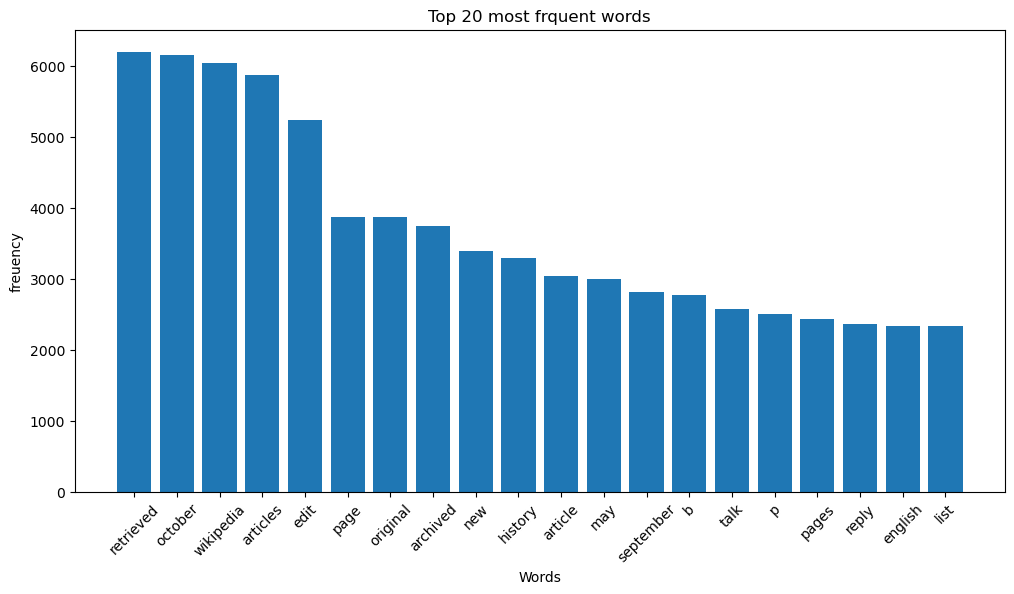

In [17]:
plt.figure(figsize=(12,6))

plt.bar(freq_df["Word"], freq_df["Frequency"])
plt.xticks(rotation=45)
plt.title("Top 20 most frquent words")
plt.xlabel("Words")
plt.ylabel("freuency")
plt.savefig('images/top20_most_freq.png')
plt.show()

The frequency distribution indicates that certain words occur significantly more often than others. These frequent words contribute heavily to statistical language models such as n-grams because higher occurrence generally corresponds to higher prediction probability.

In [18]:
print("10 Least Frequent Words\n")
list(word_freq.items())[-10:]

10 Least Frequent Words



[('wikipediaspam', 1),
 ('mspam', 1),
 ('mfilescreencast', 1),
 ('coibot', 1),
 ('bestogv', 1),
 ('larsenyuser', 1),
 ('linkspam', 1),
 ('messagesuser', 1),
 ('namespacegrid', 1),
 ('mantispa', 1)]

In [19]:
print('Average word length: ')
avg_lenght= np.mean([len(word) for word in clean_tokens])
print(round(avg_lenght,2))

Average word length: 
6.8


In [20]:
print("Longest word: ")
longest_word= max(vocabulary, key=len)
print(longest_word)
print(len(longest_word))

Longest word: 
httpstimesofindiaindiatimescomentertainmentmalayalammoviesnewsrojinthomasonkathanarthewildsorcereritisafilmthatpromisestotransportaudiencestootherworldlydimensionsarticleshow
174


The exploratory analysis confirms that the corpus contains a rich vocabulary with sufficient word occurrences. The next step is to construct statistical language models that learn relationships between consecutive words for autocomplete prediction.

# Building the Bigram Language Model

A **bigram** is a sequence of two consecutive words.

For example, consider the sentence:

> Artificial intelligence is transforming healthcare.

The generated bigrams are:

- Artificial → intelligence
- intelligence → is
- is → transforming
- transforming → healthcare

The frequency of these word pairs forms the basis of a statistical autocomplete system.

In [21]:
bigrams= list(zip(autocomplete_tokens[:-1], autocomplete_tokens[1:]))
print("Total bigrams: ", len(bigrams))

Total bigrams:  1365497


In [22]:
#displaying first 10 bigrams
bigrams[:10]

[('title', 'wikipedia'),
 ('wikipedia', 'the'),
 ('the', 'free'),
 ('free', 'encyclopedia'),
 ('encyclopedia', 'content'),
 ('content', 'wikipedia'),
 ('wikipedia', 'the'),
 ('the', 'free'),
 ('free', 'encyclopedia'),
 ('encyclopedia', 'jump')]

In [23]:
bigram_freq= Counter(bigrams)
print("Unique bigrams: ", len(bigram_freq))

Unique bigrams:  524632


In [24]:
# Top 20 most frequent bigrams
bigram_freq.most_common(20)

[(('of', 'the'), 8510),
 (('from', 'the'), 4788),
 (('in', 'the'), 4523),
 (('the', 'original'), 3663),
 (('original', 'on'), 3451),
 (('archived', 'from'), 3407),
 (('to', 'the'), 2628),
 (('and', 'the'), 1804),
 (('at', 'the'), 1756),
 (('list', 'of'), 1705),
 (('on', 'the'), 1683),
 (('retrieved', 'october'), 1500),
 (('for', 'the'), 1339),
 (('a', 'b'), 1301),
 (('on', 'october'), 1217),
 (('reply', 'reply'), 1175),
 (('by', 'the'), 1158),
 (('articles', 'with'), 1158),
 (('utc', 'reply'), 1038),
 (('is', 'a'), 1011)]

# Building the Prediction Dictionary

To make autocomplete efficient, a dictionary is created where:

Key → Current word

Value → All possible next words along with their frequencies.

This allows predictions to be generated in constant time without searching through the entire corpus.

In [25]:
autocomplete_dict= defaultdict(list)

for (first,second), freq in bigram_freq.items():
    autocomplete_dict[first].append((second,freq))

In [26]:
# Sort each prediction list according to frequency

for word in autocomplete_dict:

    autocomplete_dict[word] = sorted(
        autocomplete_dict[word],
        key=lambda x: x[1],
        reverse=True
    )

In [27]:
print("Sample Predictions for 'the':\n")
autocomplete_dict["the"][:10]

Sample Predictions for 'the':



[('original', 3663),
 ('first', 742),
 ('united', 684),
 ('new', 571),
 ('table', 390),
 ('wikimedia', 389),
 ('world', 383),
 ('university', 380),
 ('th', 380),
 ('article', 377)]

In [28]:
print("Dictionary Size :", len(autocomplete_dict))

Dictionary Size : 78091


In [29]:
def predict_bigram(word, top_n=3):
    word=word.lower()

    if word not in autocomplete_dict:
        return ["No prediction available"]

    predictions= autocomplete_dict[word][:top_n]

    return [next_word for next_word, _ in predictions]

In [30]:
predict_bigram("the")

['original', 'first', 'united']

In [31]:
test_words=[    
    "the",
    "machine",
    "artificial",
    "india",
    "science",
    "history",
    "computer",
    "language",
    "data",
    "university"
    ]

for word in test_words:
    print(f"\nInput:{word}")
    print("Prediction:", predict_bigram(word))


Input:the
Prediction: ['original', 'first', 'united']

Input:machine
Prediction: ['the', 'retrieved', 'translation']

Input:artificial
Prediction: ['intelligence', 'languages', 'dwelling']

Input:india
Prediction: ['indonesia', '–', 'and']

Input:science
Prediction: ['–', 'and', 'technology']

Input:history
Prediction: ['of', 'general', 'tools']

Input:computer
Prediction: ['science', 'scientist', 'engineering']

Input:language
Prediction: ['links', 'and', 'of']

Input:data
Prediction: ['germany', 'from', 'structure']

Input:university
Prediction: ['of', 'press', 'in']


In [32]:
sample_results= pd.DataFrame({
    "Input Word": test_words,
    "Top predictions": [predict_bigram(word)[0] for word in test_words]
})

sample_results

,Input Word,Top predictions
0,the,original
1,machine,the
2,artificial,intelligence
3,india,indonesia
4,science,–
5,history,of
6,computer,science
7,language,links
8,data,germany
9,university,of


# Evaluation of the Autocomplete Model

To evaluate the effectiveness of the autocomplete system, a small ground truth dataset is created.

For each input word, one expected next word is defined based on common word associations in the corpus. The predicted words generated by the Bigram model are then compared with these expected outputs.

The evaluation metrics used are:

- **Precision** – Measures how many predicted words are relevant.
- **Recall** – Measures how many relevant words are successfully predicted.

In [33]:
ground_truth = {
    "the": "first",
    "machine": "learning",
    "artificial": "intelligence",
    "india": "is",
    "science": "fiction",
    "history": "of",
    "computer": "science",
    "language": "is",
    "data": "analysis",
    "university": "of"
}

In [34]:
evaluation_results=[]

for word in test_words:
    predictions= predict_bigram(word)
    expected= ground_truth[word]
    correct= expected in predictions

    evaluation_results.append([word, expected, predictions, correct])

evaluation_df= pd.DataFrame(
    evaluation_results,
    columns=[
        "Word",
        "Expected",
        "Predicted",
        "Correct"
    ]
)

evaluation_df

,Word,Expected,Predicted,Correct
0,the,first,"[original, first, united]",True
1,machine,learning,"[the, retrieved, translation]",False
2,artificial,intelligence,"[intelligence, languages, dwelling]",True
3,india,is,"[indonesia, –, and]",False
4,science,fiction,"[–, and, technology]",False
5,history,of,"[of, general, tools]",True
6,computer,science,"[science, scientist, engineering]",True
7,language,is,"[links, and, of]",False
8,data,analysis,"[germany, from, structure]",False
9,university,of,"[of, press, in]",True


In [35]:
true_positive = evaluation_df["Correct"].sum()
false_positive = len(evaluation_df) - true_positive
false_negative = false_positive

In [36]:
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)

print(f"Precision : {precision:.2f}")
print(f"Recall    : {recall:.2f}")

Precision : 0.50
Recall    : 0.50


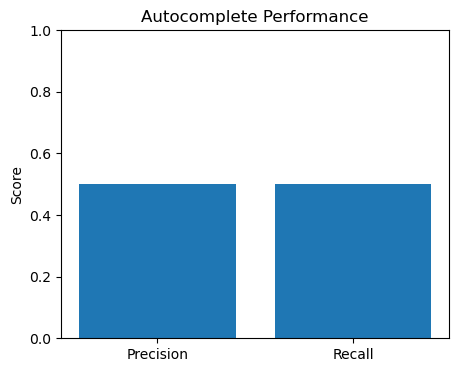

In [37]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Precision","Recall"],
    [precision, recall]
)

plt.ylim(0,1)

plt.title("Autocomplete Performance")

plt.ylabel("Score")
plt.savefig('images/Autocomp_performance.png')
plt.show()

## Autocorrect

# Part II – Autocorrect using Edit Distance

Autocomplete predicts the next word based on previously observed word sequences.

Autocorrect, on the other hand, detects spelling mistakes and suggests the most probable correct word.

Modern autocorrect systems combine multiple techniques such as edit distance, word frequency, language models and contextual understanding.

In this section, two different approaches are implemented:

1. **PySpellChecker** – A dictionary and edit-distance based spell correction library.
2. **Custom Levenshtein Distance** – A manually implemented edit-distance algorithm.

The performance of both approaches will then be compared.

In [38]:
from spellchecker import SpellChecker
spell = SpellChecker()
print("SpellChecker Loaded Successfully!")

SpellChecker Loaded Successfully!


In [43]:
#example
word="machne"
print("original word: ",word)
print("Corrected: ", spell.correction(word))

original word:  machne
Corrected:  machine


In [48]:
#more examples
example_words=["languge", "sceinc","itellegence","algorthm","recieve"]

for word in example_words:
    print("Correted: ", spell.correction(word))

Correted:  language
Correted:  scenic
Correted:  intelligence
Correted:  algorithm
Correted:  receive


In [45]:
test_words = {

    "machne":"machine",
    "langauge":"language",
    "scinece":"science",
    "algoritm":"algorithm",
    "recieve":"receive",
    "enviroment":"environment",
    "goverment":"government",
    "inteligence":"intelligence",
    "commitee":"committee",
    "seperate":"separate",
    "adress":"address",
    "occured":"occurred",
    "definately":"definitely",
    "beleive":"believe",
    "writting":"writing",
    "tommorrow":"tomorrow",
    "acheive":"achieve",
    "freind":"friend",
    "succesful":"successful",
    "neccessary":"necessary"
}

print("Total Test Words :", len(test_words))

Total Test Words : 20


In [46]:
results=[]

for wrong, correct in test_words.items():
    predictions=spell.correction(wrong)

    results.append([wrong, correct, predictions, predictions==correct])

spell_df=pd.DataFrame(
    results,
    columns=[
        "Misspelled",
        "Expected",
        "Prediction",
        "Correct"
    ]
)

spell_df

,Misspelled,Expected,Prediction,Correct
0,machne,machine,machine,True
1,langauge,language,language,True
2,scinece,science,science,True
3,algoritm,algorithm,algorithm,True
4,recieve,receive,receive,True
5,enviroment,environment,environment,True
6,goverment,government,government,True
7,inteligence,intelligence,intelligence,True
8,commitee,committee,committee,True
9,seperate,separate,separate,True


In [47]:
correct_predictions=spell_df["Correct"].sum()
accuracy= correct_predictions/len(spell_df)
print("Accuracy: ", accuracy)

Accuracy:  0.95


The accuracy obtained above indicates the percentage of misspelled words that were correctly corrected by PySpellChecker.

Although the library performs well on common spelling mistakes, more challenging errors may still require contextual language models.

# Custom Levenshtein Distance Algorithm

Although PySpellChecker provides a ready-to-use spell correction system, it hides the internal implementation.

To better understand how spelling correction works, a custom Levenshtein Distance algorithm is implemented.

The algorithm measures the minimum number of edit operations required to transform one word into another.

The word with the smallest edit distance is selected as the predicted correction.

In [49]:
def levenshtein_dist(s1, s2):

    if len(s1)<len(s2):
        return levenshtein_dist(s2,s1)

    if len(s2)==0:
        return len(s1)

    previous_row= list(range(len(s2)+1))

    for i,c1 in enumerate(s1):
        current_row= [i+1]

        for j, c2 in enumerate(s2):
            insertions= previous_row[j+1]+1
            deletions= current_row[j]+1
            substitutions=previous_row[j]+(c1!=c2)

            current_row.append(min(insertions, deletions, substitutions))

        previous_row=current_row

    return previous_row[-1]

In [50]:
dictionary= list(vocabulary)
print("Dictionary size: ",len(dictionary))

Dictionary size:  77572


In [51]:
dictionary[:20]

['threats',
 'goksedef',
 'marini',
 'deregulating',
 'templatecontents',
 'barracks',
 'anneke',
 'userexamplesubpage',
 'gunther',
 'galaxies',
 'psychoanalysis',
 'ea',
 'בצהל',
 'brackish',
 'vt',
 'thermography',
 'bombers',
 'ornamentation',
 'chaminda',
 'interfaculty']

In [52]:
def custom_autocorrect(word):

    min_distance = float("inf")
    best_word = word

    for candidate in dictionary:

        distance = levenshtein_dist(
            word,
            candidate
        )

        if distance < min_distance:
            min_distance = distance
            best_word = candidate

    return best_word

In [53]:
print(custom_autocorrect("machne"))

machine


In [54]:
custome_results=[]

for wrong, correct in test_words.items():
    predictions=custom_autocorrect(wrong)

    custome_results.append([wrong, correct, predictions, predictions==correct])

custom_df= pd.DataFrame(
    custome_results,
    columns=[
        "Wrong",
        "Expected",
        "Prediction",
        "Correct"
    ]
)

custom_df

,Wrong,Expected,Prediction,Correct
0,machne,machine,machine,True
1,langauge,language,langue,False
2,scinece,science,science,True
3,algoritm,algorithm,algorithm,True
4,recieve,receive,relieve,False
5,enviroment,environment,environment,True
6,goverment,government,government,True
7,inteligence,intelligence,intelligence,True
8,commitee,committee,committee,True
9,seperate,separate,separate,True


The custom algorithm depends entirely on the quality of the vocabulary. If the corpus contains misspelled words, those errors become valid candidates.

In [55]:
custom_correct = custom_df["Correct"].sum()
custom_accuracy = custom_correct / len(custom_df)
print(f"Custom Levenshtein Accuracy : {custom_accuracy:.2%}")

Custom Levenshtein Accuracy : 65.00%


In [56]:
comparison = pd.DataFrame({

    "Algorithm": [
        "PySpellChecker",
        "Custom Levenshtein"
    ],

    "Accuracy": [
        accuracy,
        custom_accuracy
    ]

})

comparison

,Algorithm,Accuracy
0,PySpellChecker,0.95
1,Custom Levenshtein,0.65


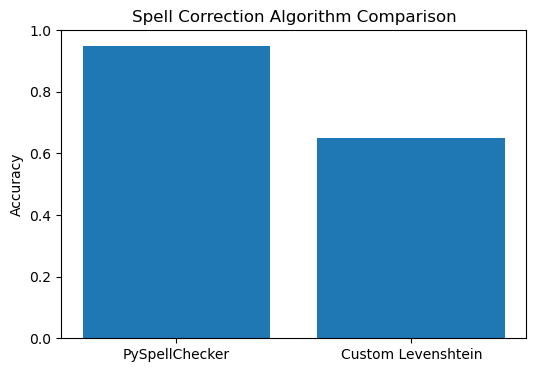

In [57]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Algorithm"],
    comparison["Accuracy"]
)

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Spell Correction Algorithm Comparison")
plt.savefig('images/accuracy_comp.png')
plt.show()

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [59]:
y_true = [1] * len(custom_df)
y_pred = custom_df["Correct"].astype(int)

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision :", precision_score(y_true, y_pred))
print("Recall :", recall_score(y_true, y_pred))

Accuracy : 0.65
Precision : 1.0
Recall : 0.65


Since the evaluation dataset contains only misspelled words, there are no true negative examples. Consequently, precision remains high while recall reflects the proportion of words that were correctly corrected. A more comprehensive evaluation could include correctly spelled words to provide a more balanced confusion matrix.

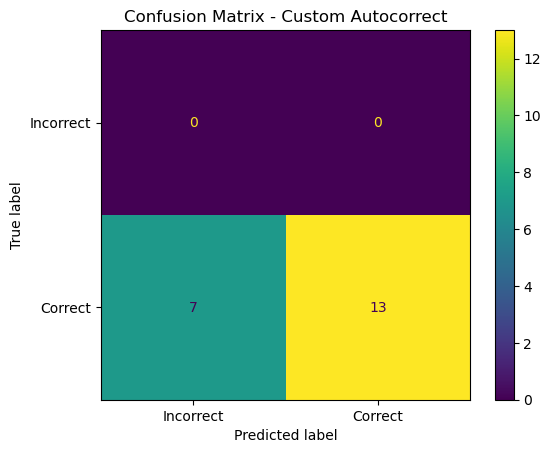

In [60]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot()

plt.title("Confusion Matrix - Custom Autocorrect")
plt.savefig('images/confusion_matrix.png')
plt.show()

# Completion of the Autocorrect Module

The autocorrect system has been successfully implemented using two different approaches:

1. PySpellChecker
2. Custom Levenshtein Distance

Both approaches were evaluated on a set of deliberately misspelled words, and their performance was compared using accuracy and additional evaluation metrics.

The following section discusses the limitations of the implemented system and compares it with production-grade autocomplete and autocorrect systems.

# Limitations of the Implemented System

Although the implemented autocomplete and autocorrect systems perform well for educational purposes, they have several limitations when compared to production-grade systems such as Google Keyboard, Microsoft SwiftKey, or Apple QuickType.

### Autocomplete Limitations

- The autocomplete model is based on **bigram frequencies**, which consider only the immediately preceding word.
- It cannot understand the overall context or meaning of a sentence.
- It does not adapt to individual user writing styles or frequently used phrases.
- Predictions are entirely dependent on the training corpus and may not generalize well to unseen text.
- The model cannot generate new phrases beyond those observed in the dataset.

### Autocorrect Limitations

- The custom Levenshtein algorithm compares every input word against the entire vocabulary, making it computationally expensive for large dictionaries.
- The algorithm relies solely on edit distance and does not consider word frequency or sentence context.
- Since the vocabulary is extracted from the corpus, any misspelled words present in the dataset may also become valid dictionary entries.
- PySpellChecker performs better due to its optimized dictionary and frequency-based ranking but still lacks contextual understanding.

### Comparison with Production Systems

Modern keyboard applications use advanced Natural Language Processing (NLP) techniques such as:

- Transformer-based language models
- Neural language models
- Context-aware prediction
- Personalized learning from user history
- Cloud-based language updates
- Semantic understanding of complete sentences

These techniques allow production systems to generate more accurate and contextually relevant suggestions than simple frequency-based or edit-distance-based approaches.